# Do areas with more Airbnb listings have higher rents?

In this notebook we will explore if there is a relationship between the number of airbnb listings and the rent values of a neighborhood. We will explore New York city boroughs and see if there is a positive relationship between the factors.

Two datasets were used in this exploration:
1. AirBnb dataset from kaggle from 2024
2. Zillow detailed dataset for property values and rent for 12 months until December 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [93]:
airbnb_df = pd.read_csv("data/new_york_listings_2024.csv")
airbnb_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1312228,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,...,2015-12-20,0.03,1,0,0,No License,5.0,1,1,Not specified
1,45277537,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,2023-05-01,0.24,139,364,2,No License,4.67,2,1,1
2,971353993633883038,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,2023-12-18,1.67,1,343,6,Exempt,4.17,1,2,1
3,3857863,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,2023-09-17,1.38,2,363,12,No License,4.64,1,1,1
4,40896611,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,2023-12-03,0.24,133,335,3,No License,4.91,Studio,1,1


Initially a raw dataset from InsideAirbnb.com was used. Upon initial exploration, all price for all listings in New York City has been stripped off, presumably due to some local laws. I ended up using a cleaner dataset from Kaggle.

In [116]:
#new york data set from insideairbnb.com has all price as nan due to local law
#check new data set if price is populated
print(airbnb_df['price'].describe())

count    20560.000000
mean       160.034339
std        128.101041
min         10.000000
25%         80.000000
50%        125.000000
75%        198.000000
max        999.000000
Name: price, dtype: float64


In [117]:
#airbnb_df.columns.tolist()

In [118]:
airbnb_df['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        7882
Brooklyn         7688
Queens           3753
Bronx             947
Staten Island     290
Name: count, dtype: int64

In [119]:
airbnb_df['room_type'].value_counts()

room_type
Entire home/apt    11402
Private room        8766
Shared room          288
Hotel room           104
Name: count, dtype: int64

In [120]:
# Keep relevant columns
airbnb_df = airbnb_df[['price', 'neighbourhood_group', 'room_type']]

# Drop missing/extreme values
airbnb_df = airbnb_df.dropna(subset=['price'])
airbnb_df = airbnb_df[airbnb_df['price'] < 1000]

# Indicator for entire home
airbnb_df['entire_home'] = np.where(airbnb_df['room_type'] == 'Entire home/apt', 1, 0)

In [121]:
airbnb_df.head()

,price,neighbourhood_group,room_type,entire_home
0,55.0,Brooklyn,Private room,0
1,144.0,Manhattan,Entire home/apt,1
2,187.0,Manhattan,Entire home/apt,1
3,120.0,Manhattan,Private room,0
4,85.0,Manhattan,Entire home/apt,1


In [122]:
airbnb_df.shape

(20560, 4)

In [123]:
#Aggregate data by borough
airbnb_borough = airbnb_df.groupby('neighbourhood_group').agg({
    'price': 'mean',
    'room_type': 'count',
    'entire_home': 'mean'
}).reset_index()

airbnb_borough.columns = ['Borough', 'avg_airbnb_price', 'num_listings', 'pct_entire_home']
airbnb_borough

,Borough,avg_airbnb_price,num_listings,pct_entire_home
0,Bronx,107.048574,947,0.411827
1,Brooklyn,153.190817,7688,0.534079
2,Manhattan,193.356762,7882,0.656179
3,Queens,120.862510,3753,0.420464
4,Staten Island,115.741379,290,0.537931


In [124]:
zillow_df = pd.read_csv("data/Zip_zori_uc_sfrcondomfr_sm_month.csv")

# Strip column spaces
zillow_df.columns = zillow_df.columns.str.strip()

# Filter NYC and make copy
nyc_zillow = zillow_df[(zillow_df['City'] == 'New York') & (zillow_df['State'] == 'NY')].copy()

'RegionName' column from the zillow datasets contain the zip code of each property

In [126]:
nyc_zillow['RegionName'].describe()

count      145.000000
mean     10761.986207
std        577.930852
min      10001.000000
25%      10044.000000
50%      11104.000000
75%      11236.000000
max      11694.000000
Name: RegionName, dtype: float64

Nice there is no neighborhood or borough column in the zillow dataset, we are mapping the zip code to a borough below:

In [108]:
zip_to_borough = {
    # Manhattan
    10001: 'Manhattan', 10002: 'Manhattan', 10003: 'Manhattan', 10004: 'Manhattan', 10005: 'Manhattan',
    10006: 'Manhattan', 10007: 'Manhattan', 10009: 'Manhattan', 10010: 'Manhattan', 10011: 'Manhattan',
    10012: 'Manhattan', 10013: 'Manhattan', 10014: 'Manhattan', 10016: 'Manhattan', 10017: 'Manhattan',
    10018: 'Manhattan', 10019: 'Manhattan', 10020: 'Manhattan', 10021: 'Manhattan', 10022: 'Manhattan',
    10023: 'Manhattan', 10024: 'Manhattan', 10025: 'Manhattan', 10026: 'Manhattan', 10027: 'Manhattan',
    10028: 'Manhattan', 10029: 'Manhattan', 10030: 'Manhattan', 10031: 'Manhattan', 10032: 'Manhattan',
    10033: 'Manhattan', 10034: 'Manhattan', 10035: 'Manhattan', 10036: 'Manhattan', 10037: 'Manhattan',
    10038: 'Manhattan', 10039: 'Manhattan', 10040: 'Manhattan',
    # Brooklyn
    11201: 'Brooklyn', 11203: 'Brooklyn', 11204: 'Brooklyn', 11205: 'Brooklyn', 11206: 'Brooklyn',
    11207: 'Brooklyn', 11208: 'Brooklyn', 11209: 'Brooklyn', 11210: 'Brooklyn', 11211: 'Brooklyn',
    11212: 'Brooklyn', 11213: 'Brooklyn', 11214: 'Brooklyn', 11215: 'Brooklyn', 11216: 'Brooklyn',
    11217: 'Brooklyn', 11218: 'Brooklyn', 11219: 'Brooklyn', 11220: 'Brooklyn', 11221: 'Brooklyn',
    11222: 'Brooklyn', 11223: 'Brooklyn', 11224: 'Brooklyn', 11225: 'Brooklyn', 11226: 'Brooklyn',
    11228: 'Brooklyn', 11229: 'Brooklyn', 11230: 'Brooklyn', 11231: 'Brooklyn', 11232: 'Brooklyn',
    11233: 'Brooklyn', 11234: 'Brooklyn', 11235: 'Brooklyn', 11236: 'Brooklyn', 11237: 'Brooklyn',
    11238: 'Brooklyn', 11239: 'Brooklyn',
    # Queens
    11354: 'Queens', 11355: 'Queens', 11356: 'Queens', 11357: 'Queens', 11358: 'Queens',
    11359: 'Queens', 11360: 'Queens', 11361: 'Queens', 11362: 'Queens', 11363: 'Queens',
    11364: 'Queens', 11365: 'Queens', 11366: 'Queens', 11367: 'Queens', 11368: 'Queens',
    11369: 'Queens', 11370: 'Queens', 11372: 'Queens', 11373: 'Queens', 11374: 'Queens',
    11375: 'Queens', 11377: 'Queens', 11378: 'Queens', 11379: 'Queens', 11385: 'Queens',
    11411: 'Queens', 11412: 'Queens', 11413: 'Queens', 11414: 'Queens', 11415: 'Queens',
    11416: 'Queens', 11417: 'Queens', 11418: 'Queens', 11419: 'Queens', 11420: 'Queens',
    11421: 'Queens', 11422: 'Queens', 11423: 'Queens', 11426: 'Queens', 11427: 'Queens',
    11428: 'Queens', 11429: 'Queens', 11432: 'Queens', 11433: 'Queens', 11434: 'Queens',
    11435: 'Queens', 11436: 'Queens',
    # Bronx
    10451: 'Bronx', 10452: 'Bronx', 10453: 'Bronx', 10454: 'Bronx', 10455: 'Bronx',
    10456: 'Bronx', 10457: 'Bronx', 10458: 'Bronx', 10459: 'Bronx', 10460: 'Bronx',
    10461: 'Bronx', 10462: 'Bronx', 10463: 'Bronx', 10464: 'Bronx', 10465: 'Bronx',
    10466: 'Bronx', 10467: 'Bronx', 10468: 'Bronx', 10469: 'Bronx', 10470: 'Bronx',
    10471: 'Bronx', 10472: 'Bronx', 10473: 'Bronx', 10474: 'Bronx', 10475: 'Bronx',
    # Staten Island
    10301: 'Staten Island', 10302: 'Staten Island', 10303: 'Staten Island', 10304: 'Staten Island',
    10305: 'Staten Island', 10306: 'Staten Island', 10307: 'Staten Island', 10308: 'Staten Island',
    10309: 'Staten Island', 10310: 'Staten Island', 10312: 'Staten Island', 10314: 'Staten Island'
}

nyc_zillow['Borough'] = nyc_zillow['RegionName'].map(zip_to_borough)
nyc_zillow = nyc_zillow.dropna(subset=['Borough'])
nyc_zillow.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2015-01-31,...,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,Borough
5,62093,7,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,NaN,...,3069.521001,3134.666050,3114.226549,3096.051753,3054.706644,3038.273513,2996.771548,3033.168664,3088.779816,Queens
7,62019,9,11208,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Kings County,NaN,...,2678.658618,2739.588027,2848.048380,2900.768375,2980.107891,3026.198306,2895.447482,2810.906289,2847.047619,Brooklyn
13,62046,16,11236,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Kings County,NaN,...,NaN,NaN,2904.949736,3007.193796,3171.945868,3222.795475,3108.258485,3188.999438,3173.611111,Brooklyn
14,61807,17,10467,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Bronx County,NaN,...,2417.697304,2536.078848,2608.847347,2531.822226,2584.390050,2560.947240,2571.408597,2488.592947,2547.766667,Bronx
15,62085,18,11373,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,NaN,...,2245.587260,2326.264460,2341.346120,2356.593483,2340.296150,2359.580904,2423.246891,2426.524607,2392.944444,Queens


In [110]:
# Identify all month columns
date_cols = [col for col in nyc_zillow.columns if col[:4].isdigit() and '-' in col]

# Option 1: latest month
latest_month = date_cols[-1]
nyc_zillow['rent_latest'] = nyc_zillow[latest_month]

# Option 2: 12-month average
nyc_zillow['rent_avg_12mo'] = nyc_zillow[date_cols[-12:]].mean(axis=1)

In [111]:
#Aggregate rent by borough
borough_rent = nyc_zillow.groupby('Borough')['rent_avg_12mo'].mean().reset_index()
borough_rent.rename(columns={'rent_avg_12mo': 'avg_rent'}, inplace=True)

In [113]:
#Merge airbnb and zillow
merged_df = pd.merge(airbnb_borough, borough_rent, on='Borough')
merged_df

,Borough,avg_airbnb_price,num_listings,pct_entire_home,avg_rent
0,Bronx,107.048574,947,0.411827,2698.347192
1,Brooklyn,153.190817,7688,0.534079,3148.309540
2,Manhattan,193.356762,7882,0.656179,4182.377871
3,Queens,120.862510,3753,0.420464,2669.732483
4,Staten Island,115.741379,290,0.537931,2517.130342


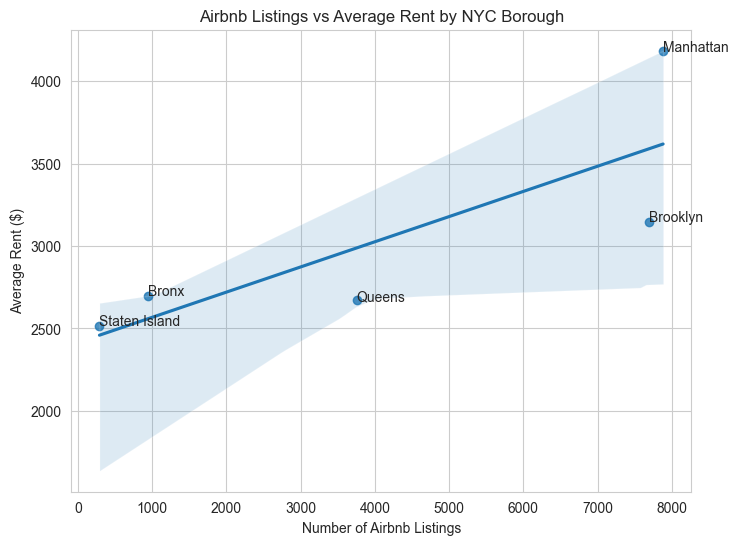

In [114]:
plt.figure(figsize=(8,6))
sns.regplot(data=merged_df, x='num_listings', y='avg_rent')

for i in range(len(merged_df)):
    plt.text(merged_df['num_listings'][i], merged_df['avg_rent'][i], merged_df['Borough'][i])

plt.xlabel("Number of Airbnb Listings")
plt.ylabel("Average Rent ($)")
plt.title("Airbnb Listings vs Average Rent by NYC Borough")
plt.show()


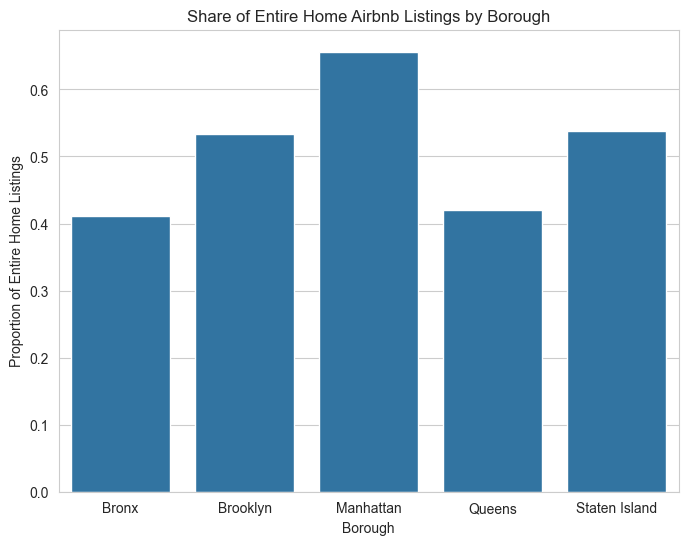

In [115]:
plt.figure(figsize=(8,6))
sns.barplot(data=merged_df, x='Borough', y='pct_entire_home')
plt.ylabel("Proportion of Entire Home Listings")
plt.title("Share of Entire Home Airbnb Listings by Borough")
plt.show()


There is a a clear positive relationship between the number of listings and rent prices. Manhattan has the most listings and also the highest rent while staten island has the lowest number of listing and the lowest rent